# **RBC Stock Price Prediction Using ARIMA**

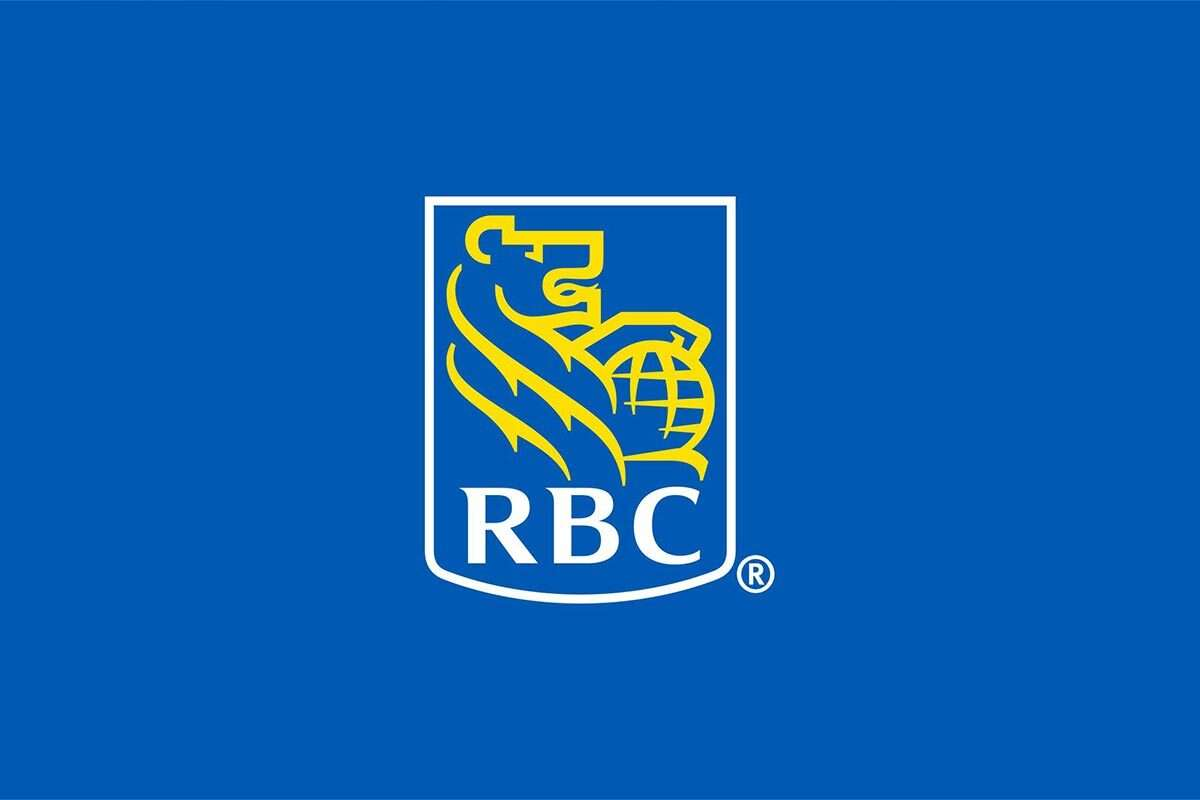

## 1. **Introduction**

Royal Bank of Canada (RY on TSX and NYSE) is one of Canada's biggest banks, and among the largest in the world based on market capitalization. They provide personal and commercial banking, wealth management, insurance, investor services and capital markets products and services on a global basis.

Autoregressive Integrated Moving Average (ARIMA) Model are generalizations of the autoregressive moving average (ARMA) model to non-stationary series and periodic variation, respectively. All these models are fitted to time series in order to better understand it and predict future values. The purpose of these generalizations is to fit the data as well as possible. Specifically, ARMA assumes that the series is stationary, that is, its expected value is constant in time. If instead the series has a trend (but a constant variance/autocovariance), the trend is removed by "differencing",leaving a stationary series.

ARIMA model has been used extensively in the field of finance and economics as it is known to be robust, efficient and has a strong potential for short-term share market prediction.

The aim of this project will be to predict the stock price of RBC using ARIMA. The data in this project has been obtained from the yfinance api python library

Links:
1. https://en.wikipedia.org/wiki/Autoregressive_integrated_moving_average
2. https://en.wikipedia.org/wiki/Royal_Bank_of_Canada

## 2.**Data Ingestion and Cleaning** 

In [1]:
#Import Libraries
import os
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fivethirtyeight')
from pylab import rcParams
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
#from statsmodels.tsa.arima_model import ARIMA
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math
from pmdarima.arima import auto_arima
import yfinance as yf

In [2]:
# Define the ticker symbol
ticker = 'RY'

# Get historical market data
data = yf.download(ticker, start='2020-01-01', end='2025-01-01')

df = pd.DataFrame(data)
df

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,RY,RY,RY,RY,RY
Date,,,,,
2020-01-02,65.949997,66.016197,65.519711,65.652104,758100
2020-01-03,65.718307,65.916907,65.395592,65.470068,543200
2020-01-06,65.858971,65.875524,65.461785,65.610731,1304500
2020-01-07,65.676933,65.916903,65.561087,65.792780,969300
2020-01-08,66.074127,66.380296,65.552818,65.627288,809000
...,...,...,...,...,...
2024-12-24,120.739998,120.849998,120.330002,120.690002,282600
2024-12-26,121.080002,121.330002,120.379997,120.379997,281800


### **Glossary of Terms**:
1. **Date**: Date of trade
2. **Close**: Closing Price
3. **High**: Peak Price
4. **Low**: Lowest Price
5. **Open**: Opening Price
6. **Volume**: Trade Volume

All prices are in USD

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   (Close, RY)   1258 non-null   float64
 1   (High, RY)    1258 non-null   float64
 2   (Low, RY)     1258 non-null   float64
 3   (Open, RY)    1258 non-null   float64
 4   (Volume, RY)  1258 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 59.0 KB


In [4]:
df.isnull().sum()

Price   Ticker
Close   RY        0
High    RY        0
Low     RY        0
Open    RY        0
Volume  RY        0
dtype: int64

Luckily, there is no need to clean the data as all trades are automated. Nevertheless, the data has to be transformed as the dataframe is using a MultiIndex for columns as it has multiple header rows

In [5]:
#Check the index and columns
print(df.index.name)         
print(df.columns)

Date
MultiIndex([( 'Close', 'RY'),
            (  'High', 'RY'),
            (   'Low', 'RY'),
            (  'Open', 'RY'),
            ('Volume', 'RY')],
           names=['Price', 'Ticker'])


In [6]:
#Flatten the MultiIndex columns
df.columns = [col[0] for col in df.columns] 
print(df.columns)

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


In [7]:
#Reset the index to date
df = df.reset_index()

## 3. Descriptive Analysis

In [8]:
df.describe()

,Close,High,Low,Open,Volume
count,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03
mean,87.670307,88.287039,87.000662,87.636788,1.065150e+06
std,17.186436,17.191519,17.141676,17.163072,7.482645e+05
min,41.456974,45.351138,41.406833,44.340005,1.435000e+05
25%,80.499920,80.979509,79.100690,80.270587,6.232000e+05
50%,90.095161,90.649769,89.450717,90.081367,8.296500e+05
75%,96.009106,96.674248,95.364348,95.991017,1.232650e+06
max,128.020004,128.050003,125.970001,127.650002,7.576900e+06


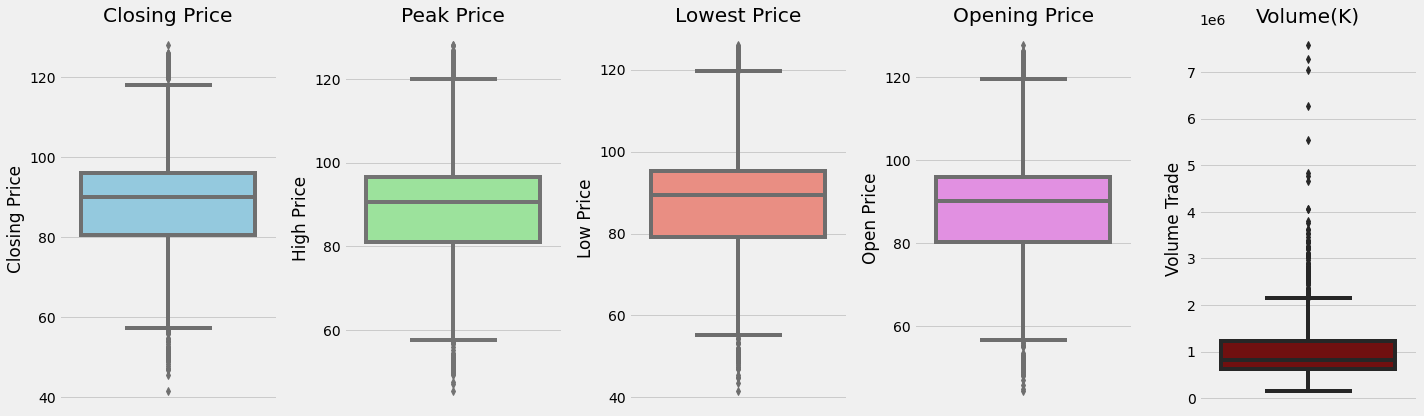

In [9]:
plt.figure(figsize=(20,6))

plt.subplot(1,5,1)
sns.boxplot(y=df['Close'],color='skyblue')
plt.title("Closing Price")
plt.ylabel('Closing Price')


plt.subplot(1,5,2)
sns.boxplot(y=df['High'],color='lightgreen')
plt.title("Peak Price")
plt.ylabel('High Price')

plt.subplot(1,5,3)
sns.boxplot(y=df['Low'],color='salmon')
plt.title("Lowest Price")
plt.ylabel('Low Price')

plt.subplot(1,5,4)
sns.boxplot(y=df['Open'],color='violet')
plt.title("Opening Price")
plt.ylabel('Open Price')

plt.subplot(1,5,5)
sns.boxplot(y=df['Volume'],color='maroon')
plt.title("Volume(K)")
plt.ylabel('Volume Trade')

plt.tight_layout()
plt.show()

### **Observations:**
1. The stock shows steady growth and relatively low daily volatility (difference between High, Low, Open, and Close).

2. Volume is highly variable, indicating some days experience intense trading (possibly news-related).

3. There are potential outliers based on the volume alone with very low min and mean values(1.435000e+05,1.065150e+06) and a high max value(7.576900e+06). Nevertheless, they'll be kept as the ARIMA model is designed to handle it.


## 4. Exploratory Data Analysis

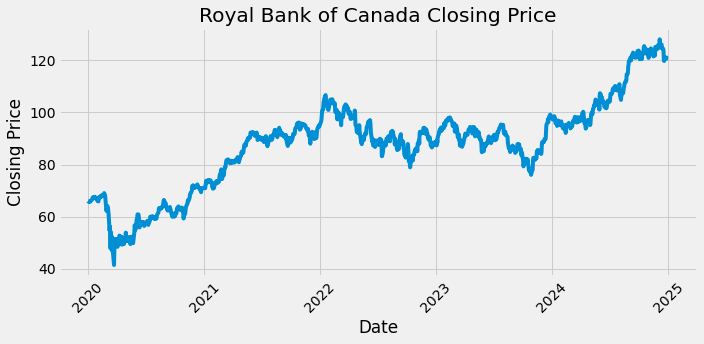

In [10]:
# Plot line graph
plt.figure(figsize=(10, 5))

plt.plot(
    df['Date'].to_numpy(), 
    df['Close'].to_numpy(), 
)
plt.title('Royal Bank of Canada Closing Price')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

### **Observations:**
The price has an all time low of ~41 in 2020 during the pandemic and a peak of ~130 towards the end of 2024. It is trending upwards although it had a small dip of ~78 in late 2023.

Text(0.5, 0, 'Closing Price')

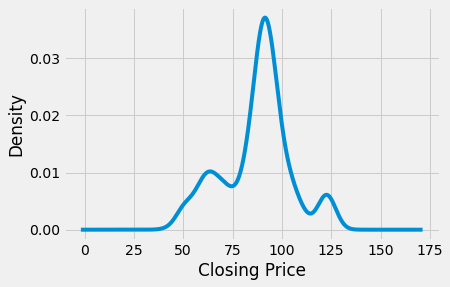

In [11]:
df["Close"].plot(kind='kde')
plt.xlabel('Closing Price')

### **Observations:**

1. The highest peak is around 90–95, suggesting that most of the closing prices clustered around this value.
2. There are two smaller peaks. Firstly around 60–65, indicating some historical concentration of prices in that region and again around 120–125, indicating more recent higher prices (likely due to stock appreciation).
3. The distribution has multiple peaks (multimodal) indicating that the stock price had distinct phases or clusters of values over the given time: pre-COVID dip, recovery phase, and recent highs).

## 5. Auto Regressive Integrated Moving Average

A time series is thought to consist of three systematic components including level, trend, seasonality, and one non-systematic component called noise.These components are defined as follows:
1. Level: The average value in the series.

2. Trend: The increasing or decreasing value in the series.

3. Seasonality: The repeating short-term cycle in the series.

4. Noise: The random variation in the series.

First, we need to check if a series is stationary or not because time series analysis only works with stationary data. We can use the Dickey-Fuller test which is a statistical test used to determine if a time series has a unit root, meaning it is likely non-stationary.

The null and alternate hypothesis of this test are as follows:

**Null Hypothesis**: The series has a unit root (value of a =1)

**Alternate Hypothesis**: The series has no unit root.

If we fail to reject the null hypothesis, we can say that the series is non-stationary. This means that the series can be linear or difference stationary.However, if both mean and standard deviation are flat lines(constant mean and constant variance), the series becomes stationary.

In [12]:
# Set index to date
df=df.set_index("Date")

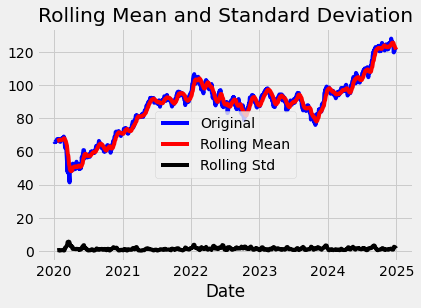

Results of dickey fuller test
Test Statistics                  -0.799671
p-value                           0.819219
No. of lags used                  7.000000
Number of observations used    1250.000000
critical value (1%)              -3.435592
critical value (5%)              -2.863855
critical value (10%)             -2.568003
dtype: float64


In [13]:
#Test for stationarity
def test_stationarity(timeseries):
    
    
    timeseries.index = pd.to_datetime(timeseries.index)
    #Determing rolling statistics
    rolmean = timeseries.rolling(12).mean()
    rolstd = timeseries.rolling(12).std()
    #Plot rolling statistics:
    plt.plot(timeseries, color='blue',label='Original')
    plt.plot(rolmean, color='red', label='Rolling Mean')
    plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.xlabel("Date")
    plt.title('Rolling Mean and Standard Deviation')
    plt.show(block=False)
    
    print("Results of dickey fuller test")
    adft = adfuller(timeseries,autolag='AIC')
    # output for dft will give us without defining what the values are.
    #hence we manually write what values does it explains using a for loop
    output = pd.Series(adft[0:4],index=['Test Statistics','p-value','No. of lags used','Number of observations used'])
    for key,values in adft[4].items():
        output['critical value (%s)'%key] =  values
    print(output)
    
test_stationarity(df["Close"])

### **Observations:**
Based on the graphs and results of the test, our data can be assumed to be non-stationary. However, we cannot fully reject our Null Hypothesis as it has a p-value >0.05.
Also, the test statistics is greater than the critical values so the data is non-stationary.

To carryout our prediction we need to decompose our time series into it's seasonal and trend parts.

<Figure size 432x288 with 0 Axes>

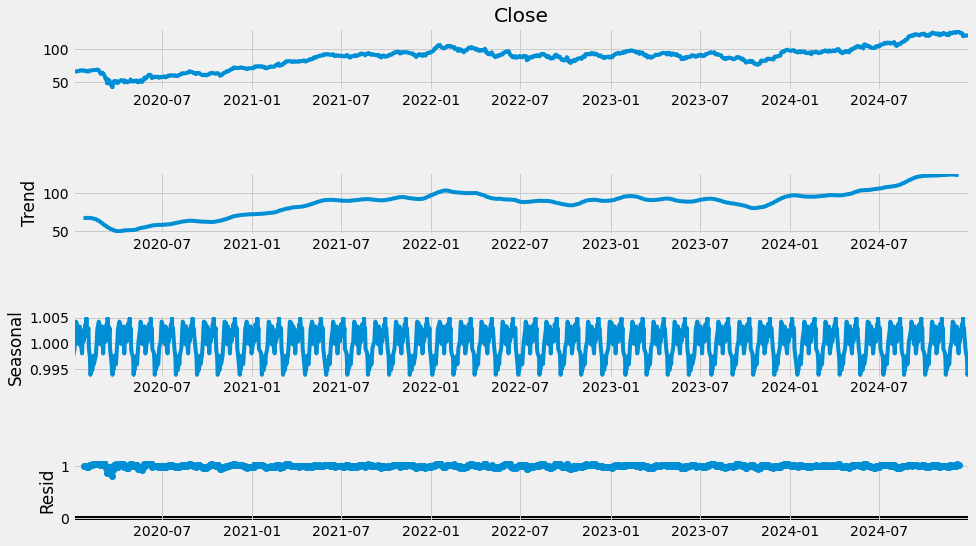

In [14]:
#To separate the trend and the seasonality from a time series, 
# we can decompose the series using the following code.
result = seasonal_decompose(df["Close"], model='multiplicative',period=30)
fig = plt.figure()  
fig = result.plot()  
fig.set_size_inches(16, 9)

To  reduce the magnitude of the values and reduce the rising trend in the series, we takeke the log of the prices in the time series, and express daily returns in terms of changes to the log price. This gives us a fat-tailed, approximately normal, distribution.Then after getting the log of the series, we find the rolling average of the series. A rolling average is calculated by taking input for the past 12 months and giving a mean consumption value at every point further ahead in series.

No handles with labels found to put in legend.


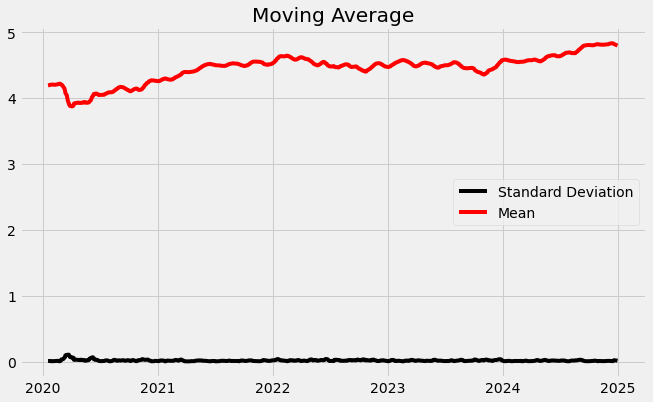

In [15]:
rcParams['figure.figsize'] = 10, 6
df_log = np.log(df["Close"])
moving_avg = df_log.rolling(12).mean()
std_dev = df_log.rolling(12).std()
plt.legend(loc='best')
plt.title('Moving Average')
plt.plot(std_dev, color ="black", label = "Standard Deviation")
plt.plot(moving_avg, color="red", label = "Mean")
plt.legend()
plt.show()

## 6. Predictive Modelling

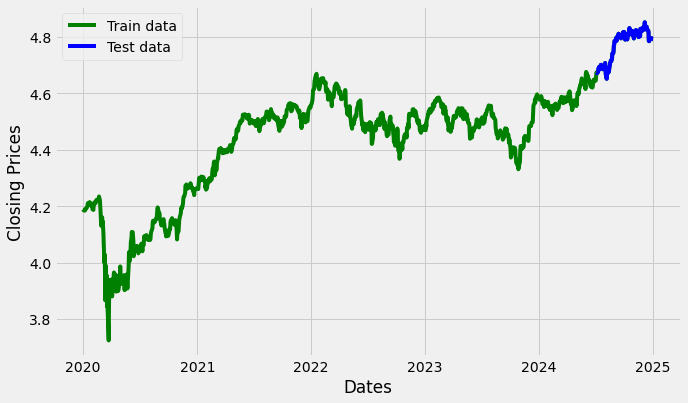

In [16]:
#split data into train and training set
train_data, test_data = df_log[3:int(len(df_log)*0.9)], df_log[int(len(df_log)*0.9):]
plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(df_log, 'green', label='Train data')
plt.plot(test_data, 'blue', label='Test data')
plt.legend()

I will now choose parameters p,d,q for ARIMA model. ARIMA models are usually denoted ARIMA(p, d, q) where parameters p, d, q are non-negative integers: p is the order (number of time lags) of the autoregressive model, d is the degree of differencing (the number of times the data have had past values subtracted), and q is the order of the moving-average model. For this model, I will use Auto ARIMA

The auto_arima function seeks to identify the most optimal parameters for an ARIMA model, and returns a fitted ARIMA model. This function is based on the commonly-used R function, forecast::auto.arima.

The auro_arima function works by conducting differencing tests (i.e., Kwiatkowski–Phillips–Schmidt–Shin, Augmented Dickey-Fuller or Phillips–Perron) to determine the order of differencing, d, and then fitting models within ranges of defined start_p, max_p, start_q, max_q ranges. If the seasonal optional is enabled, auto_arima also seeks to identify the optimal P and Q hyper- parameters after conducting the Canova-Hansen to determine the optimal order of seasonal differencing, D.

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-6184.198, Time=0.21 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-6189.018, Time=0.24 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-6188.691, Time=0.12 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-6185.372, Time=0.07 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-6187.547, Time=0.68 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-6187.356, Time=0.43 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-6185.540, Time=0.49 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=-6190.061, Time=0.09 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=-6188.630, Time=0.13 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=-6188.408, Time=0.17 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=-6189.730, Time=0.22 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=-6186.622, Time=0.20 sec

Best model:  ARIMA(1,1,0)(0,0,0)[0]          
Total fit time: 3.077 seconds
                               SARIMAX Results                              

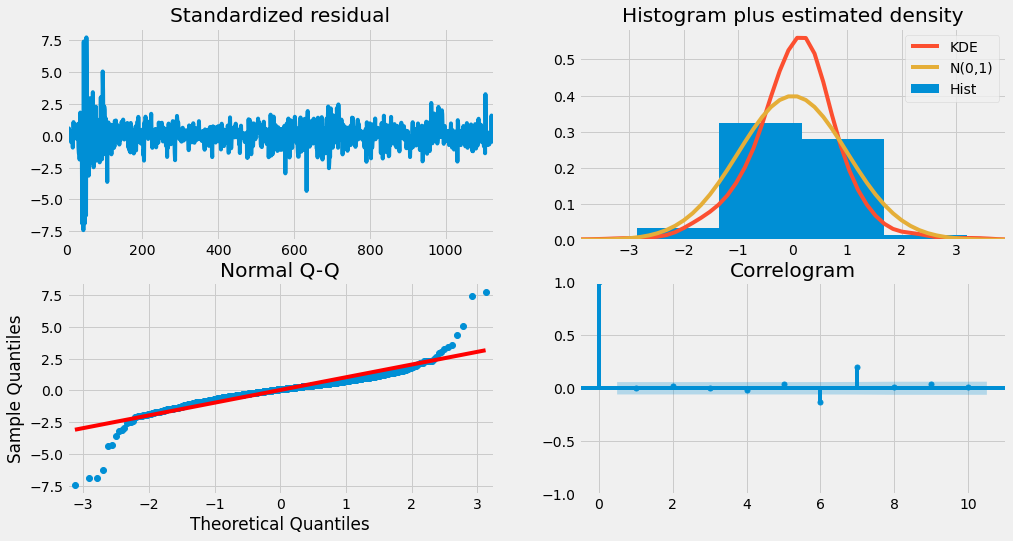

In [17]:
model_autoARIMA = auto_arima(train_data, start_p=0, start_q=0,
                      test='adf',       # use adftest to find optimal 'd'
                      max_p=3, max_q=3, # maximum p and q
                      m=1,              # frequency of series
                      d=None,           # let model determine 'd'
                      seasonal=False,   # No Seasonality
                      start_P=0, 
                      D=0, 
                      trace=True,
                      error_action='ignore',  
                      suppress_warnings=True, 
                      stepwise=True)
print(model_autoARIMA.summary())
model_autoARIMA.plot_diagnostics(figsize=(15,8))
plt.show()

### **Observations:**

**Standardized Residuals**: The residual errors seem to fluctuate around a mean of zero and have a uniform variance.But the early residuals show larger spikes, indicating possible non-stationarity at the beginning or a structural change.

**Histogram + KDE + Normal Curve**: The density plot suggest some mild deviation from normality.

**Normal Q-Q Plot**: All the dots should fall perfectly in line with the red line. Any significant deviations would imply the distribution is skewed.Central points lie close to the red line, meaning normality in the center. But tails deviate, especially on the right — again suggesting heavy-tailed distribution (common in finance)

**Correlogram (ACF of residuals)**: The Correlogram, aka, ACF plot shows the residual errors are not autocorrelated. Any autocorrelation would imply that there is some pattern in the residual errors which are not explained in the model. So you will need to look for more X’s (predictors) to the model.The first lag is expectedly high (due to differencing). Subsequent lags are close to zero, with most within the confidence bounds, indicating residuals are uncorrelated — a good sign.

Overall, it seems to be a good fit. Next, I will create an ARIMA model with provided optimal parameters p, d and q

In [18]:
# Build Model
model = ARIMA(train_data, order=(1, 1, 0))
fitted = model.fit()
print(fitted.summary())


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 1129
Model:                 ARIMA(1, 1, 0)   Log Likelihood                3097.030
Date:                Wed, 30 Apr 2025   AIC                          -6190.061
Time:                        00:22:15   BIC                          -6180.004
Sample:                             0   HQIC                         -6186.261
                               - 1129                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0769      0.010     -7.399      0.000      -0.097      -0.057
sigma2         0.0002   3.71e-06     65.089      0.000       0.000       0.000
Ljung-Box (L1) (Q):                   0.00   Jarque-

C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [19]:
# Forecast next 126 steps
forecast_result = fitted.get_forecast(steps=126)

# Get forecasted mean
fc = forecast_result.predicted_mean

# Get confidence intervals
conf = forecast_result.conf_int()

# (Optional) Standard error of forecast
se = forecast_result.se_mean  # if you really need standard errors

C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


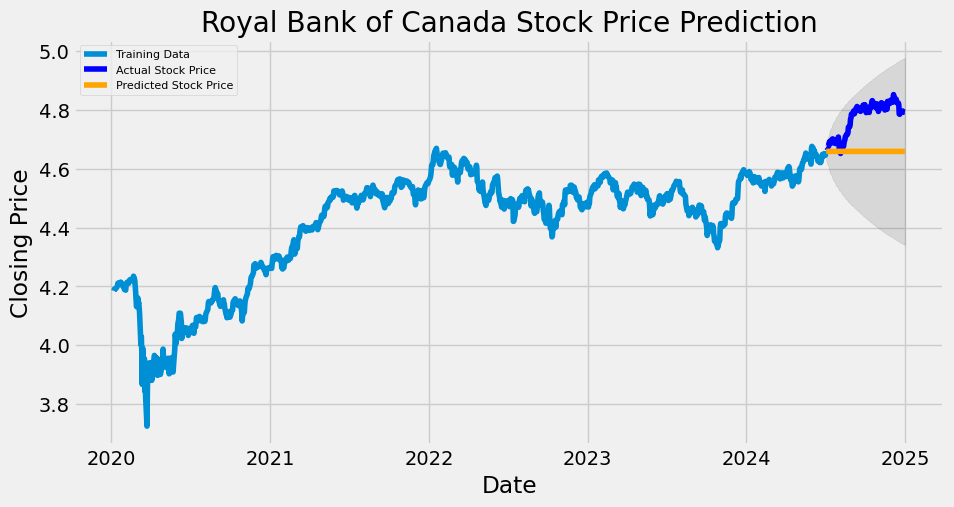

In [20]:
# Ensure indexes match
fc.index = test_data.index
conf.index = test_data.index

# Recreate Series
fc_series = pd.Series(fc, index=test_data.index)
lower_series = pd.Series(conf.iloc[:, 0], index=test_data.index)
upper_series = pd.Series(conf.iloc[:, 1], index=test_data.index)

# Plot
plt.figure(figsize=(10, 5), dpi=100)
plt.plot(train_data, label='Training Data')
plt.plot(test_data, label='Actual Stock Price', color='blue')
plt.plot(fc_series, label='Predicted Stock Price', color='orange')
plt.fill_between(lower_series.index, lower_series, upper_series, color='k', alpha=0.1)
plt.title('Royal Bank of Canada Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend(loc='upper left', fontsize=8)

plt.show()

### **Observations:**
**Performance Interpretation:**

**Strengths:**
1. **Trend Tracking**:  
   The model successfully captures the general upward trend seen in the stock over the years.
   
2. **Stable Forecast**:  
   The forecast is relatively smooth and conservative. This makes it reliable for long-term directional trends rather than short-term spikes.

3. **Confidence Interval Inclusion**:  
   The actual prices fall within the forecast interval, indicating that the model’s uncertainty bounds are well-calibrated.

**Weaknesses / Limitations:**
1. **Underfitting in Forecast Period**:
   The forecast is flat, while the actual stock continues rising.This suggests the model might not be fully capturing recent momentum or seasonality. ARIMA tends to struggle with non-linear trends, sudden changes, or volatility.

2. **Lag in Reacting to Market Changes**:  
   ARIMA models assume past values explain future ones. But if macro events affect stock prices, the model won’t adapt quickly.


In [21]:
# report performance
mse = mean_squared_error(test_data, fc)
print('MSE: '+str(mse))
mae = mean_absolute_error(test_data, fc)
print('MAE: '+str(mae))
rmse = math.sqrt(mean_squared_error(test_data, fc))
print('RMSE: '+str(rmse))
mape = np.mean(np.abs(fc - test_data)/np.abs(test_data))
print('MAPE: '+str(mape))

MSE: 0.016408389417516135
MAE: 0.11527556819308232
RMSE: 0.12809523573309092
MAPE: 0.024010161760800043


### **Observations:**
The ARIMA model is statistically solid: low error rates and tight confidence intervals.

Despite visually appearing a bit flat in the forecast, the predicted values are very close to the actual ones, as evidenced by the low MAPE.The MAPE is very low for this model suggesting a model accuracy of 97.6%.

On average, the prediction is off by about 0.12, which is reasonable depending on the stock price range. The range for this model is roughly 3.7–5.

The small forecast variance is actually a good sign in financial forecasting, where overfitting can be more dangerous than underfitting.

### **Recommendations:**
Consider switching to or comparing with: 

1. Prophet (by Meta) for more flexibility and trend/seasonality detection.

2. Hybrid models(ARIMA + XGBoost/LSTM) to capture both linear and non-linear patterns.